# Anemi Tahmin Modeli

Bu projede, hastaların tam kan sayımı (CBC) verileri, hemoglobin, hematokrit ve demir paneli değerleri kullanılarak anemi (kansızlık) durumları ve olası anemi türleri tahmin edilmektedir.

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

Dataset: https://www.kaggle.com/datasets/biswaranjanrao/anemia-dataset

1. **Gender:** 0 - male, 1 - female

2. **Hemoglobin:** Kırmızı kan hücrelerinde bulunan, organ ve dokulara oksijen taşıyan; buralardaki karbondioksiti ise geri atılması için akciğerlere ileten protein miktarıdır.

3. **MCH:** Her bir kırmızı kan hücresinin (alyuvarın) içinde bulunan ortalama hemoglobin miktarını gösteren parametredir.

4. **MCHC:** Tek bir kırmızı kan hücresinin içindeki hemoglobin yoğunluğunun (konsantrasyonunun) ortalama ölçümüdür.

5. **MCV:** Kırmızı kan hücrelerinin ortalama boyutunu ve hacmini ölçen parametredir.

6. **Results:** Hedef Değişken (0 - not anemic, 1 -anemic)

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("anemia.csv")
display(df.head())
print(df.isna().sum())
print("\n")
print(df.info())
display(df.describe())
print("\nEtiket Dağılımı:")
print(df['Result'].value_counts(normalize=True))

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB
None


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000



Etiket Dağılımı:
Result
0    0.563688
1    0.436312
Name: proportion, dtype: float64


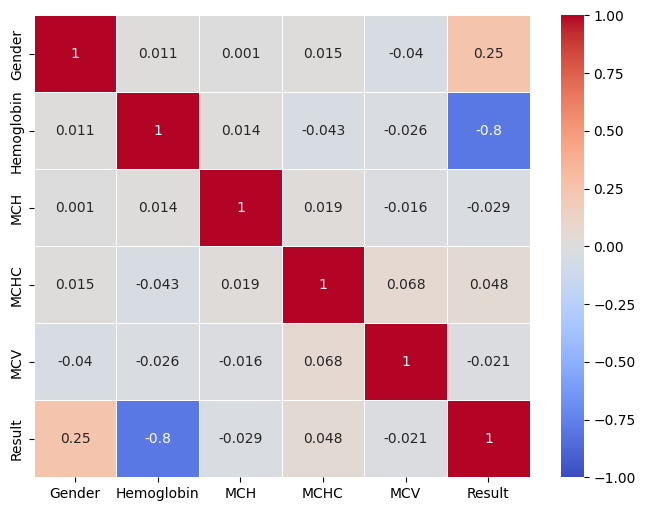

In [3]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [5]:
X=df.drop(columns=["Result"])
y=df["Result"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [6]:
models={
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Support Vector Classifier": SVC(kernel='rbf', random_state=42),
    "K-Nearest neighbors Classifier": KNeighborsClassifier(n_neighbors=5)
}

In [7]:
results_list = []

for name, model in models.items():
    
    if name == "Random Forest Classifier" or name == "Gradient Boosting Classifier" or name == "Decision Tree Classifier":
        model.fit(X_train, y_train)
        y_pred=model.predict(X_test)
        cm=confusion_matrix(y_pred,y_test)
        cr=classification_report(y_pred,y_test)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred=model.predict(X_test_scaled)
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    cm=confusion_matrix(y_test,y_pred)
    cr_dict = classification_report(y_test, y_pred, output_dict=True)
    target_class = '1' if '1' in cr_dict else (1 if 1 in cr_dict else list(cr_dict.keys())[1])
    recall_anemia = cr_dict[target_class]['recall']
    f1_anemia = cr_dict[target_class]['f1-score']
    
    results_list.append({
        "Model Name": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "5-Fold CV Mean": round(cv_scores.mean(), 4),
        "Anemia Recall (Class 1)": round(recall_anemia, 4),
        "Anemia F1-Score (Class 1)": round(f1_anemia, 4),
        "Confusion Matrix": cm.tolist()
    })
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
display(results_df.style.hide(axis="index"))

Model Name,Train Accuracy,Test Accuracy,5-Fold CV Mean,Anemia Recall (Class 1),Anemia F1-Score (Class 1),Confusion Matrix
Random Forest Classifier,1.000000,1.000000,1.000000,1.000000,1.000000,"[[157, 0], [0, 128]]"
Gradient Boosting Classifier,1.000000,1.000000,1.000000,1.000000,1.000000,"[[157, 0], [0, 128]]"
Decision Tree Classifier,1.000000,1.000000,1.000000,1.000000,1.000000,"[[157, 0], [0, 128]]"
Support Vector Classifier,0.992100,0.982500,0.991200,1.000000,0.980800,"[[152, 5], [0, 128]]"
K-Nearest neighbors Classifier,0.984200,0.961400,0.943600,0.953100,0.956900,"[[152, 5], [6, 122]]"


In [8]:
import pickle
import os
os.makedirs('../models', exist_ok=True)
with open('../models/anemia_model.pkl', 'wb') as f:
    pickle.dump(models["Random Forest Classifier"], f)